In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
insurance_data = pd.read_csv("01_insurance.csv")

In [3]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
#Create useful and interacted features
X = insurance_data.drop(columns = ["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns = ["region", "sex", "smoker"], drop_first = True, dtype = int)
#Creating new features

X["bmi_smoker"] = X["bmi"] * X["smoker_yes"]
X["age_smoker"] = X["age"] * X["smoker_yes"]
X.head()

,age,bmi,children,region_northwest,region_southeast,region_southwest,sex_male,smoker_yes,bmi_smoker,age_smoker
0,19,27.900,0,0,0,1,0,1,27.9,19
1,18,33.770,1,0,1,0,1,0,0.0,0
2,28,33.000,3,0,1,0,1,0,0.0,0
3,33,22.705,0,1,0,0,1,0,0.0,0
4,32,28.880,0,1,0,0,1,0,0.0,0


In [5]:
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size = 0.1, random_state = 42)

In [6]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
y_predict = model.predict(X_test)

In [8]:
index = 0
print(y_predict[index])
print(y_test.iloc[index])

11300.791820620194
9095.06825


In [9]:
r2 = r2_score(y_test,y_predict)
print("R_squared:",r2)

R_squared: 0.8505499160069414


<Axes: xlabel='bmi', ylabel='charges'>

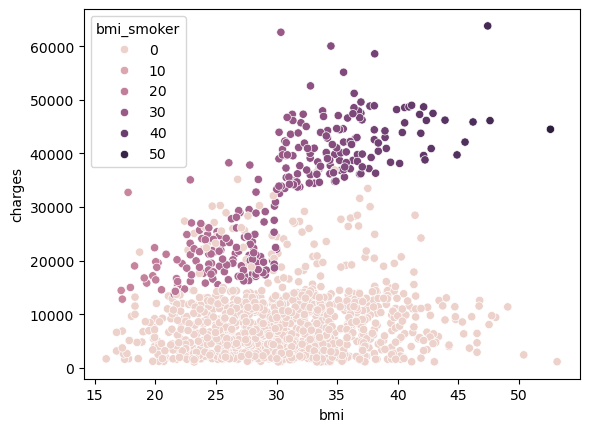

In [10]:
#this time our model improved
X = X.assign(charges = insurance_data["charges"])
sns.scatterplot(
    data = X,
    x = "bmi",
    y = "charges",
    hue = "bmi_smoker" 
)

In [11]:
X

,age,bmi,children,region_northwest,region_southeast,region_southwest,sex_male,smoker_yes,bmi_smoker,age_smoker,charges
0,19,27.900,0,0,0,1,0,1,27.90,19,16884.92400
1,18,33.770,1,0,1,0,1,0,0.00,0,1725.55230
2,28,33.000,3,0,1,0,1,0,0.00,0,4449.46200
3,33,22.705,0,1,0,0,1,0,0.00,0,21984.47061
4,32,28.880,0,1,0,0,1,0,0.00,0,3866.85520
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,1,0,0,1,0,0.00,0,10600.54830
1334,18,31.920,0,0,0,0,0,0,0.00,0,2205.98080
1335,18,36.850,0,0,1,0,0,0,0.00,0,1629.83350
1336,21,25.800,0,0,0,1,0,0,0.00,0,2007.94500
